# South India rice: complete preprocessing
Three raw sources → one master CSV → standard and DAE training splits.

The complete code is visible below. Saved tables and plots are from the verified 08 October 2026 run. Run all cells to reproduce in Colab. This trains the preprocessing DAE only; it does not train the final yield models.

**Preprocessing:** SimpleImputer, StandardScaler, OneHotEncoder, Denoising Autoencoder.

**Future yield models:** HistGradientBoostingRegressor, Multilayer Perceptron, Long Short-Term Memory and one-dimensional CNN.

In [ ]:
from pathlib import Path
import subprocess, sys
repo = Path("/content/south-india-crop-yield-dataset")
dataset_url = "https://github.com/ritwik1612/south-india-crop-yield-dataset.git"
if not repo.exists():
    subprocess.run(["git", "clone", dataset_url, str(repo)], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(repo / "pre-processing/requirements.txt")], check=True)
sys.path.insert(0, str(repo / "pre-processing"))
dataset = repo / "DATASET"
print("Raw files:", list((dataset / "raw").rglob("*.csv")))
print("Master:", dataset / "merged/rice_master.csv")


## 1. Build the merged table from the raw files
Input: raw/government/crop_statistics.csv, raw/boundaries/india_districts.geojson.zip, raw/weather/daily_weather.csv. Temporary crop/area/location join tables exist only during construction.

In [ ]:
__file__ = str(repo / "pre-processing/build_dataset.py")
sys.argv = [__file__, "--dataset-dir", str(dataset)]
"""Rebuild the single master CSV from the three preserved raw sources.

Intermediate join tables exist only inside a TemporaryDirectory; users manage
only raw/, merged/ and training/. No simulated observations are added.
"""
import argparse
import csv
import json
import math
import re
import shutil
import subprocess
import sys
import tempfile
import zipfile
from collections import defaultdict
from pathlib import Path

STATES = ('Andhra Pradesh', 'Karnataka', 'Tamil Nadu', 'Telangana')
ROOT = Path(__file__).resolve().parents[1]

def key(value):
    return re.sub(r'[^A-Z0-9]', '', ' '.join(value.strip().upper().replace('&','AND').split()))

def write_csv(path, rows):
    if not rows:
        raise ValueError(f'No rows available for {path.name}')
    with path.open('w',newline='',encoding='utf-8') as f:
        writer=csv.DictWriter(f,fieldnames=list(rows[0])); writer.writeheader(); writer.writerows(rows)

def main():
    ap=argparse.ArgumentParser(description=__doc__)
    ap.add_argument('--dataset-dir',type=Path,default=ROOT/'DATASET')
    args=ap.parse_args(); raw=args.dataset_dir/'raw'; merged=args.dataset_dir/'merged'
    merged.mkdir(parents=True,exist_ok=True)
    source=[]
    with (raw/'government/crop_statistics.csv').open(newline='',encoding='utf-8-sig') as f:
        for row in csv.DictReader(f):
            state=row['State'].strip()
            if state not in STATES: continue
            try:
                area=float(row['Area ']); production=float(row['Production']); year=int(row['Crop_Year'])
            except (ValueError,TypeError): continue
            if not math.isfinite(area) or not math.isfinite(production) or area<=0 or production<0: continue
            source.append(dict(STATE=state,DISTRICT=row['District '].strip(),CROP=row['Crop'].strip(),
                               FYEAR=year,SEASON=row['Season'].strip(),CROP_AREA_HA=area,PRODUCTION_TONNES=production))
    source.sort(key=lambda r:(r['STATE'],r['DISTRICT'],r['CROP'],r['FYEAR'],r['SEASON']))
    with zipfile.ZipFile(raw/'boundaries/india_districts.geojson.zip') as archive:
        member=next(name for name in archive.namelist() if name.endswith('.json'))
        with archive.open(member) as f: boundaries=json.load(f)['features']
    state_keys={key(s):s for s in STATES}; gadm={}; district_keys=defaultdict(list)
    for feature in boundaries:
        props=feature['properties']; state=state_keys.get(key(props.get('NAME_1',''))); district=props.get('NAME_2')
        if state not in STATES or not district: continue
        geometry=feature['geometry']; points=[]
        for polygon in geometry['coordinates']:
            rings=polygon if geometry['type']=='MultiPolygon' else [polygon]
            for ring in rings: points.extend(ring)
        gadm[(state,key(district))]=(district,sum(p[0] for p in points)/len(points),sum(p[1] for p in points)/len(points))
    for state,district_key in gadm: district_keys[district_key].append((state,district_key))
    centroids=[]
    for state,district in sorted({(r['STATE'],r['DISTRICT']) for r in source}):
        match=gadm.get((state,key(district))); status='exact_normalised'
        if not match and len(district_keys[key(district)])==1:
            match=gadm[district_keys[key(district)][0]]; status='historical_state_crosswalk'
        if match:
            name,lon,lat=match
            centroids.append(dict(IDREGION=f'IND_{key(state)}_{key(district)}',STATE=state,DISTRICT=district,
                                  GADM_DISTRICT=name,CENTROID_X=round(lon,6),CENTROID_Y=round(lat,6),MATCH_STATUS=status))
    rice=[r for r in source if r['CROP'].strip().lower() in {'rice','paddy'}]
    totals=defaultdict(float)
    for r in rice: totals[(r['STATE'],r['FYEAR'],r['SEASON'])]+=r['CROP_AREA_HA']
    labels=[]; areas=[]; fractions=[]
    for r in rice:
        region=f"IND_{key(r['STATE'])}_{key(r['DISTRICT'])}"
        context=dict(IDREGION=region,FYEAR=r['FYEAR'],SEASON=r['SEASON'])
        labels.append(dict(CROP='Rice',**context,YIELD=round(r['PRODUCTION_TONNES']/r['CROP_AREA_HA'],6),PRODUCTION_TONNES=r['PRODUCTION_TONNES']))
        areas.append(dict(CROP_ID='Rice',**context,CROP_AREA=r['CROP_AREA_HA']))
        fractions.append(dict(CROP_ID='Rice',**context,FRACTION=round(r['CROP_AREA_HA']/totals[(r['STATE'],r['FYEAR'],r['SEASON'])],8)))
    with tempfile.TemporaryDirectory(prefix='rice-join-') as temp:
        stage=Path(temp)
        for filename,rows in [('YIELD_NUTS2_SOUTH_INDIA_RICE.csv',labels),('CROP_AREA_NUTS2_SOUTH_INDIA_RICE.csv',areas),
                              ('AREA_FRACTIONS_NUTS2_SOUTH_INDIA_RICE.csv',fractions),('CENTROIDS_NUTS2_SOUTH_INDIA.csv',centroids)]:
            write_csv(stage/filename,rows)
        # A read-only hard link avoids copying the 57 MB weather extract.
        weather_stage=stage/'METEO_DAILY_NUTS2_SOUTH_INDIA.csv'
        try:
            weather_stage.hardlink_to(raw/'weather/daily_weather.csv')
        except OSError:
            shutil.copy2(raw/'weather/daily_weather.csv',weather_stage)
        subprocess.run([sys.executable,str(Path(__file__).parent/'internal/merge_seasonal.py'),
                        '--data-dir',str(stage),'--output-dir',str(merged)],check=True)
        generated=merged/'south_india_rice_master_training.csv'
        generated.replace(merged/'rice_master.csv')
    print(f"Sources: 3 | valid four-state crop rows: {len(source)} | rice labels: {len(labels)}")

if __name__=='__main__': main()


## 2. Inspect the master, coverage and missing values
A row is a rice district-year-season observation. Yield labels are retained separately from predictors.

In [ ]:
import pandas as pd
master = pd.read_csv(dataset / "merged/rice_master.csv")
display(master.head())
display(master.groupby("STATE").size().rename("Rows").to_frame())
display(master.isna().sum().rename("Missing").to_frame())
print(master.shape)


STATE,DISTRICT,FYEAR,SEASON,YIELD,CROP_AREA,PREC_TOTAL,TAVG_MEAN
Andhra Pradesh,ADILABAD,2001,Kharif,2.231999,67358.0,716.2899999999995,25.849781420765037
Andhra Pradesh,ADILABAD,2001,Rabi,2.390967,9786.0,70.94000000000001,27.78641666666667
Andhra Pradesh,ANANTAPUR,2001,Kharif,2.907993,32878.0,539.3799999999998,25.71803278688524
Andhra Pradesh,ANANTAPUR,2001,Rabi,2.857,38119.0,46.78,28.068833333333323
Andhra Pradesh,CHITTOOR,2001,Kharif,2.268983,24377.0,625.73,24.594535519125664


## 3. Conventional preprocessing — complete code
Fit medians, scaling and category mapping on 2001–2015 only. Validation is 2016–2017; test is 2018–2019. The 21 predictors match the DAE experiment.

In [ ]:
__file__ = str(repo / "pre-processing/preprocess_master.py")
artifacts = repo / "pre-processing/artifacts"
sys.argv = [__file__, "--master-path", str(dataset / "merged/rice_master.csv"), "--output-dir", str(dataset / "training/standard"), "--artifacts-dir", str(artifacts)]
"""Produce conventional training CSVs from the same 21 predictors used by the DAE."""
import argparse
import json
import pickle
from pathlib import Path
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from denoising_autoencoder import select_numeric_features, chronological_split, one_hot_encoder, CATEGORICAL_FEATURES, METADATA_COLUMNS

def main():
    parser=argparse.ArgumentParser(description=__doc__)
    parser.add_argument('--master-path',type=Path,required=True)
    parser.add_argument('--output-dir',type=Path,required=True)
    parser.add_argument('--artifacts-dir',type=Path,required=True)
    args=parser.parse_args()
    args.output_dir.mkdir(parents=True,exist_ok=True); args.artifacts_dir.mkdir(parents=True,exist_ok=True)
    data=pd.read_csv(args.master_path).dropna(subset=['YIELD'])
    numeric=select_numeric_features(data); splits=chronological_split(data)
    processor=ColumnTransformer([
        ('numeric',Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]),numeric),
        ('categorical',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',one_hot_encoder())]),CATEGORICAL_FEATURES),
    ])
    processor.fit(splits['train'][numeric+CATEGORICAL_FEATURES])
    names=processor.get_feature_names_out().tolist()
    for name,split in splits.items():
        features=pd.DataFrame(processor.transform(split[numeric+CATEGORICAL_FEATURES]),columns=names)
        result=pd.concat([split[METADATA_COLUMNS].reset_index(drop=True),features],axis=1)
        result.to_csv(args.output_dir/f'{name}.csv',index=False)
    with (args.artifacts_dir/'standard_preprocessor.pkl').open('wb') as f: pickle.dump(processor,f)
    report=dict(source=str(args.master_path),numeric_features=numeric,categorical_features=CATEGORICAL_FEATURES,
                predictor_columns=names,target='YIELD',split_rows={k:len(v) for k,v in splits.items()})
    (args.artifacts_dir/'standard_manifest.json').write_text(json.dumps(report,indent=2),encoding='utf-8')
    print(json.dumps(report,indent=2))

if __name__=='__main__': main()


## 4. Denoising Autoencoder — complete code
21 numeric inputs → 64 → 32 → 8 latent features → 32 → 64 → 21 reconstruction. Gaussian corruption is added during training. Clean inputs are reconstruction targets. YIELD and PRODUCTION_TONNES never enter the encoder.

In [ ]:
__file__ = str(repo / "pre-processing/denoising_autoencoder.py")
deep = dataset / "training/autoencoder"
sys.argv = [__file__, "--model-ready-path", str(dataset / "merged/rice_master.csv"), "--output-dir", str(deep), "--epochs", "180"]
"""Deep-learning preprocessing for the South India rice-yield project.

This script turns the joined model-ready table into a denoised latent-feature
dataset. It deliberately complements, rather than replaces, transparent data
cleaning: joins, quality rules and unit-aware seasonal aggregation happen first;
the autoencoder then learns a compact representation of the numeric variables.

Model basis: Denoising Autoencoder (DAE), an established unsupervised feature
learning method introduced by Vincent et al. (ICML 2008), DOI
10.1145/1390156.1390294. This implements that published model family for this
project's train-only tabular features; it is not a pretrained agriculture model.

Recommended input is the consolidated training table built from the raw crop,
boundary and NASA POWER weather sources:
    python denoising_autoencoder.py \
        --model-ready-path DATASET/merged/rice_master.csv \
        --output-dir DATASET/training/autoencoder
"""


import argparse
import copy
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


CORE_NUMERIC_FEATURES = [
    "CROP_AREA", "CENTROID_X", "CENTROID_Y", "WEATHER_DAY_COUNT",
    "TMAX_MEAN", "TMIN_MEAN", "TAVG_MEAN", "VPRES_MEAN", "WSPD_MEAN",
    "PREC_TOTAL", "ET0_TOTAL", "RAD_TOTAL", "RELH_MEAN", "PS_MEAN",
    "GDD_BASE10",
]
MASTER_EXTRA_NUMERIC_FEATURES = [
    "AREA_FRACTION", "TEMP_RANGE_MEAN", "WATER_BALANCE_PROXY",
    "RAIN_PER_GDD", "RADIATION_PER_GDD", "CROP_AREA_LOG1P",
]
CATEGORICAL_FEATURES = ["STATE", "SEASON"]
METADATA_COLUMNS = ["IDREGION", "STATE", "DISTRICT", "FYEAR", "SEASON", "YIELD"]


def select_numeric_features(data: pd.DataFrame) -> list[str]:
    """Select valid non-leaking numeric inputs for either supported input table.

    `PRODUCTION_TONNES` is intentionally absent: yield is derived from
    production divided by crop area, so it would leak the target. Crop year,
    district identifiers and match-status fields remain provenance metadata.
    """
    missing_core = [feature for feature in CORE_NUMERIC_FEATURES if feature not in data.columns]
    if missing_core:
        raise ValueError(f"The input table is missing required numeric columns: {missing_core}")
    return [
        feature for feature in [*CORE_NUMERIC_FEATURES, *MASTER_EXTRA_NUMERIC_FEATURES]
        if feature in data.columns
    ]


class DenoisingAutoencoder(nn.Module):
    """A compact nonlinear encoder/decoder for standardized numeric features."""

    def __init__(self, input_dim: int, latent_dim: int, dropout: float) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.GELU(),
            nn.Linear(32, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.GELU(),
            nn.Linear(32, 64), nn.GELU(),
            nn.Linear(64, input_dim),
        )

    def forward(self, values: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        latent = self.encoder(values)
        return self.decoder(latent), latent


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Train a denoising autoencoder for tabular preprocessing.")
    parser.add_argument("--model-ready-path", type=Path, required=True)
    parser.add_argument("--output-dir", type=Path, required=True)
    parser.add_argument("--epochs", type=int, default=180)
    parser.add_argument("--batch-size", type=int, default=64)
    parser.add_argument("--latent-dim", type=int, default=8)
    parser.add_argument("--noise-std", type=float, default=0.05)
    parser.add_argument("--dropout", type=float, default=0.10)
    parser.add_argument("--learning-rate", type=float, default=1e-3)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--patience", type=int, default=25)
    return parser.parse_args()


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def chronological_split(data: pd.DataFrame) -> dict[str, pd.DataFrame]:
    years = sorted(data["FYEAR"].unique())
    if len(years) < 7:
        raise ValueError("At least seven crop years are required for chronological splitting.")
    return {
        "train": data.loc[~data["FYEAR"].isin(years[-4:])].copy(),
        "validation": data.loc[data["FYEAR"].isin(years[-4:-2])].copy(),
        "test": data.loc[data["FYEAR"].isin(years[-2:])].copy(),
    }


def one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_comparison_figures(
    raw_train: pd.DataFrame,
    scaled_train: np.ndarray,
    reconstructed_train: np.ndarray,
    scaler: Pipeline,
    output_dir: Path,
    history: pd.DataFrame,
    numeric_features: list[str],
) -> None:
    """Create reproducible raw-versus-DL-preprocessed comparison figures."""
    sns.set_theme(style="whitegrid", context="notebook")
    selected = [feature for feature in ["CROP_AREA", "PREC_TOTAL", "TAVG_MEAN", "RAD_TOTAL"] if feature in numeric_features]
    selected_indices = [numeric_features.index(feature) for feature in selected]
    fig, axes = plt.subplots(len(selected), 2, figsize=(12, 13), constrained_layout=True)
    fig.suptitle("Raw features versus standardized preprocessing", fontsize=15, fontweight="bold")
    for row, (feature, index) in enumerate(zip(selected, selected_indices)):
        sns.histplot(raw_train[feature], bins=30, kde=True, color="#2F6F9F", ax=axes[row, 0])
        axes[row, 0].set_title(f"{feature}: raw values")
        axes[row, 0].set_xlabel("Original unit")
        sns.histplot(scaled_train[:, index], bins=30, kde=True, color="#E8892C", ax=axes[row, 1])
        axes[row, 1].axvline(0, color="#222222", linestyle="--", linewidth=1)
        axes[row, 1].set_title(f"{feature}: standardized input")
        axes[row, 1].set_xlabel("Z-score")
    fig.savefig(output_dir / "05_raw_vs_standardized_features.png", dpi=200)
    plt.close(fig)

    actual = scaler.named_steps["scaler"].inverse_transform(scaled_train)
    reconstructed = scaler.named_steps["scaler"].inverse_transform(reconstructed_train)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    for axis, feature in zip(axes, ["TAVG_MEAN", "PREC_TOTAL"]):
        index = numeric_features.index(feature)
        axis.scatter(actual[:, index], reconstructed[:, index], alpha=0.55, s=18, color="#3A7D44")
        limits = [min(actual[:, index].min(), reconstructed[:, index].min()), max(actual[:, index].max(), reconstructed[:, index].max())]
        axis.plot(limits, limits, "--", color="#222222", linewidth=1)
        axis.set_title(f"Autoencoder reconstruction: {feature}")
        axis.set_xlabel("Standard-preprocessed value restored to original unit")
        axis.set_ylabel("Autoencoder reconstruction")
    fig.savefig(output_dir / "06_autoencoder_reconstruction.png", dpi=200)
    plt.close(fig)

    fig, axis = plt.subplots(figsize=(8, 4.5))
    axis.plot(history["epoch"], history["train_mse"], label="Training MSE", color="#2F6F9F")
    axis.plot(history["epoch"], history["validation_mse"], label="Validation MSE", color="#E8892C")
    axis.set_title("Denoising autoencoder training history")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Reconstruction MSE")
    axis.legend()
    fig.tight_layout()
    fig.savefig(output_dir / "07_autoencoder_training_loss.png", dpi=200)
    plt.close(fig)


def main() -> None:
    args = parse_args()
    if args.epochs < 1 or args.batch_size < 2 or args.latent_dim < 1 or args.patience < 1:
        raise ValueError("Epochs, latent dimension and patience must be positive; batch size must be >= 2.")
    torch.set_num_threads(2)
    set_seed(args.seed)
    output_dir = args.output_dir
    output_dir.mkdir(parents=True, exist_ok=True)
    data = pd.read_csv(args.model_ready_path).dropna(subset=["YIELD"]).copy()
    numeric_features = select_numeric_features(data)
    data[numeric_features] = data[numeric_features].replace([np.inf, -np.inf], np.nan)
    splits = chronological_split(data)
    missing_columns = splits["train"][numeric_features].isna().all()
    if missing_columns.any():
        raise ValueError(f"Entirely missing training columns: {missing_columns[missing_columns].index.tolist()}")

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot_encoder()),
    ])
    categorical_transformer = ColumnTransformer(
        [("categorical", categorical_pipeline, CATEGORICAL_FEATURES)],
        remainder="drop",
    )
    train_numeric = numeric_pipeline.fit_transform(splits["train"][numeric_features])
    train_categories = categorical_transformer.fit_transform(splits["train"][CATEGORICAL_FEATURES])
    prepared_numeric = {"train": train_numeric}
    prepared_categories = {"train": train_categories}
    for name in ("validation", "test"):
        prepared_numeric[name] = numeric_pipeline.transform(splits[name][numeric_features])
        prepared_categories[name] = categorical_transformer.transform(splits[name][CATEGORICAL_FEATURES])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = DenoisingAutoencoder(len(numeric_features), args.latent_dim, args.dropout).to(device)
    optimiser = torch.optim.AdamW(model.parameters(), lr=args.learning_rate, weight_decay=1e-4)
    loss_function = nn.MSELoss()
    train_tensor = torch.tensor(train_numeric, dtype=torch.float32)
    loader = DataLoader(TensorDataset(train_tensor), batch_size=args.batch_size, shuffle=True,
                        drop_last=len(train_tensor) % args.batch_size == 1)
    validation_tensor = torch.tensor(prepared_numeric["validation"], dtype=torch.float32, device=device)
    history_rows: list[dict[str, float]] = []
    best_loss, best_state, best_epoch, stale_epochs = float("inf"), None, 0, 0
    for epoch in range(1, args.epochs + 1):
        model.train()
        losses: list[float] = []
        for (clean_batch,) in loader:
            clean_batch = clean_batch.to(device)
            noisy_batch = clean_batch + torch.randn_like(clean_batch) * args.noise_std
            reconstructed, _ = model(noisy_batch)
            loss = loss_function(reconstructed, clean_batch)
            optimiser.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            losses.append(float(loss.detach().cpu()))
        model.eval()
        with torch.no_grad():
            reconstructed_validation, _ = model(validation_tensor)
            validation_loss = float(loss_function(reconstructed_validation, validation_tensor).cpu())
        history_rows.append({"epoch": epoch, "train_mse": float(np.mean(losses)), "validation_mse": validation_loss})
        if validation_loss < best_loss:
            best_loss, best_epoch = validation_loss, epoch
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
        if stale_epochs >= args.patience:
            break

    if best_state is None:
        raise ValueError("Training did not produce a finite validation loss.")
    model.load_state_dict(best_state)

    history = pd.DataFrame(history_rows)
    history.to_csv(output_dir / "autoencoder_training_history.csv", index=False)
    model.eval()
    all_reconstructions: dict[str, np.ndarray] = {}
    all_latents: dict[str, np.ndarray] = {}
    with torch.no_grad():
        for name, values in prepared_numeric.items():
            tensor = torch.tensor(values, dtype=torch.float32, device=device)
            reconstruction, latent = model(tensor)
            all_reconstructions[name] = reconstruction.cpu().numpy()
            all_latents[name] = latent.cpu().numpy()

    category_names = categorical_transformer.get_feature_names_out().tolist()
    for name, split in splits.items():
        latent_columns = [f"AE_LATENT_{index:02d}" for index in range(1, args.latent_dim + 1)]
        deep_features = pd.DataFrame(all_latents[name], columns=latent_columns)
        category_features = pd.DataFrame(prepared_categories[name], columns=category_names)
        reconstruction_mse = ((prepared_numeric[name] - all_reconstructions[name]) ** 2).mean(axis=1)
        result = pd.concat(
            [split[METADATA_COLUMNS].reset_index(drop=True), deep_features, category_features], axis=1,
        )
        result["AE_RECONSTRUCTION_MSE"] = reconstruction_mse
        result.to_csv(output_dir / f"rice_yield_{name}_deep_processed.csv", index=False)

    actual_train = numeric_pipeline.named_steps["scaler"].inverse_transform(train_numeric)
    reconstructed_train = numeric_pipeline.named_steps["scaler"].inverse_transform(all_reconstructions["train"])
    comparison = pd.DataFrame({
        "feature": numeric_features,
        "raw_mean": actual_train.mean(axis=0),
        "raw_std": actual_train.std(axis=0),
        "standardized_mean": train_numeric.mean(axis=0),
        "standardized_std": train_numeric.std(axis=0),
        "autoencoder_reconstruction_mae": np.abs(actual_train - reconstructed_train).mean(axis=0),
    })
    comparison.to_csv(output_dir / "raw_vs_deep_preprocessed_comparison.csv", index=False)
    make_comparison_figures(
        splits["train"], train_numeric, all_reconstructions["train"],
        numeric_pipeline, output_dir, history, numeric_features,
    )

    torch.save({
        "model_state_dict": model.state_dict(),
        "numeric_features": numeric_features,
        "latent_dim": args.latent_dim,
        "dropout": args.dropout,
        "numeric_preprocessor": numeric_pipeline,
        "categorical_preprocessor": categorical_transformer,
    }, output_dir / "rice_yield_denoising_autoencoder.pt")
    report = {
        "purpose": "Denoising autoencoder feature-learning preprocessing; not synthetic-data generation.",
        "input_rows": int(len(data)),
        "split_rows": {name: int(len(split)) for name, split in splits.items()},
        "numeric_features": numeric_features,
        "categorical_features": CATEGORICAL_FEATURES,
        "latent_dim": args.latent_dim,
        "architecture": [len(numeric_features), 64, 32, args.latent_dim, 32, 64, len(numeric_features)],
        "epochs": args.epochs,
        "epochs_completed": len(history_rows),
        "best_epoch": best_epoch,
        "best_validation_reconstruction_mse": best_loss,
        "input_path": str(args.model_ready_path),
        "predictor_columns": latent_columns + category_names + ["AE_RECONSTRUCTION_MSE"],
        "noise_std": args.noise_std,
        "dropout": args.dropout,
        "device": str(device),
    }
    (output_dir / "deep_preprocessing_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
    print(json.dumps(report, indent=2))


if __name__ == "__main__":
    main()



## 5. Put outputs into the training, artifacts and documentation folders
The training folder contains only train/validation/test CSVs and the safe-column manifest. Weights and transforms go to preprocessing artifacts; plots and findings go to docs.

In [ ]:
import shutil, json
figures = repo / "docs/figures"
reports = repo / "docs/preprocessing"
for path in (artifacts, figures, reports): path.mkdir(parents=True, exist_ok=True)
for split in ('train','validation','test'):
    (deep/f'rice_yield_{split}_deep_processed.csv').replace(deep/f'{split}.csv')
for path in list(deep.iterdir()):
    if path.suffix=='.pt': destination=artifacts/'denoising_autoencoder.pt'
    elif path.suffix=='.png': destination=figures/path.name
    elif path.name not in ('train.csv','validation.csv','test.csv'): destination=reports/path.name
    else: continue
    shutil.move(str(path),str(destination))
report=json.loads((reports/'deep_preprocessing_report.json').read_text(encoding='utf-8'))
categories=json.loads((artifacts/'standard_manifest.json').read_text(encoding='utf-8'))['predictor_columns']
predictor_columns=[f'AE_LATENT_{i:02d}' for i in range(1,report['latent_dim']+1)]
# OneHotEncoder names in the DAE transformer match the standard transformer.
predictor_columns += [name for name in categories if name.startswith('categorical__')]
predictor_columns += ['AE_RECONSTRUCTION_MSE']
manifest={'standard':{'train':'standard/train.csv','validation':'standard/validation.csv','test':'standard/test.csv',
                      'predictor_columns':categories},
          'autoencoder':{'train':'autoencoder/train.csv','validation':'autoencoder/validation.csv','test':'autoencoder/test.csv',
                         'predictor_columns':predictor_columns},
          'target':'YIELD','metadata_columns':['IDREGION','STATE','DISTRICT','FYEAR','SEASON'],
          'split_rows':report['split_rows']}
(dataset/'training/manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')
print('Ready: DATASET/training/standard and DATASET/training/autoencoder. See manifest.json for safe predictor selection.')


## 6. Output verification and model-ready rows
Standard: 28 predictors. DAE: 16 predictors (8 latent + 7 categorical + reconstruction error). Six metadata/target fields are retained in addition. Use the manifest to select X and YIELD to select y.

In [ ]:
subprocess.run([sys.executable, str(repo / "pre-processing/verify_outputs.py")], check=True)
manifest = json.loads((dataset / "training/manifest.json").read_text())
for arm in ("standard", "autoencoder"):
    train = pd.read_csv(dataset / "training" / manifest[arm]["train"])
    display(train.head())
    print(arm, "rows:", len(train), "predictors:", len(manifest[arm]["predictor_columns"]))


{
  "rows": 2018,
  "columns": 30,
  "state_counts": {
    "Karnataka": 722,
    "Tamil Nadu": 612,
    "Andhra Pradesh": 572,
    "Telangana": 112
  },
  "season_counts": {
    "Kharif": 1037,
    "Rabi": 492,
    "Summer": 345,
    "Winter": 75,
    "Autumn": 69
  },
  "missing_master_cells": 0,
  "representations": {
    "standard": {
      "train": {
        "rows": 1485,
        "predictors": 28
      },
      "validation": {
        "rows": 245,
        "predictors": 28
      },
      "test": {
        "rows": 288,
        "predictors": 28
      }
    },
    "autoencoder": {
      "train": {
        "rows": 1485,
        "predictors": 16
      },
      "validation": {
        "rows": 245,
        "predictors": 16
      },
      "test": {
        "rows": 288,
        "predictors": 16
      }
    }
  },
  "unseen_validation_test_seasons": [
    "Autumn",
    "Winter"
  ],
  "checks_passed": [
    "split membership",
    "label preservation",
    "no duplicate master keys",
    "fin

## 7. Informative graphs and measured learning
Coverage is unequal across states/seasons. Scaling changes units; DAE loss measures reconstruction. Best validation reconstruction MSE was 0.07724 at epoch 178, not a yield accuracy score. Autumn/Winter are unseen training categories and require separate evaluation.

In [ ]:
subprocess.run([sys.executable, str(repo / "pre-processing/make_figures.py")], check=True)

### Observation coverage by state and season

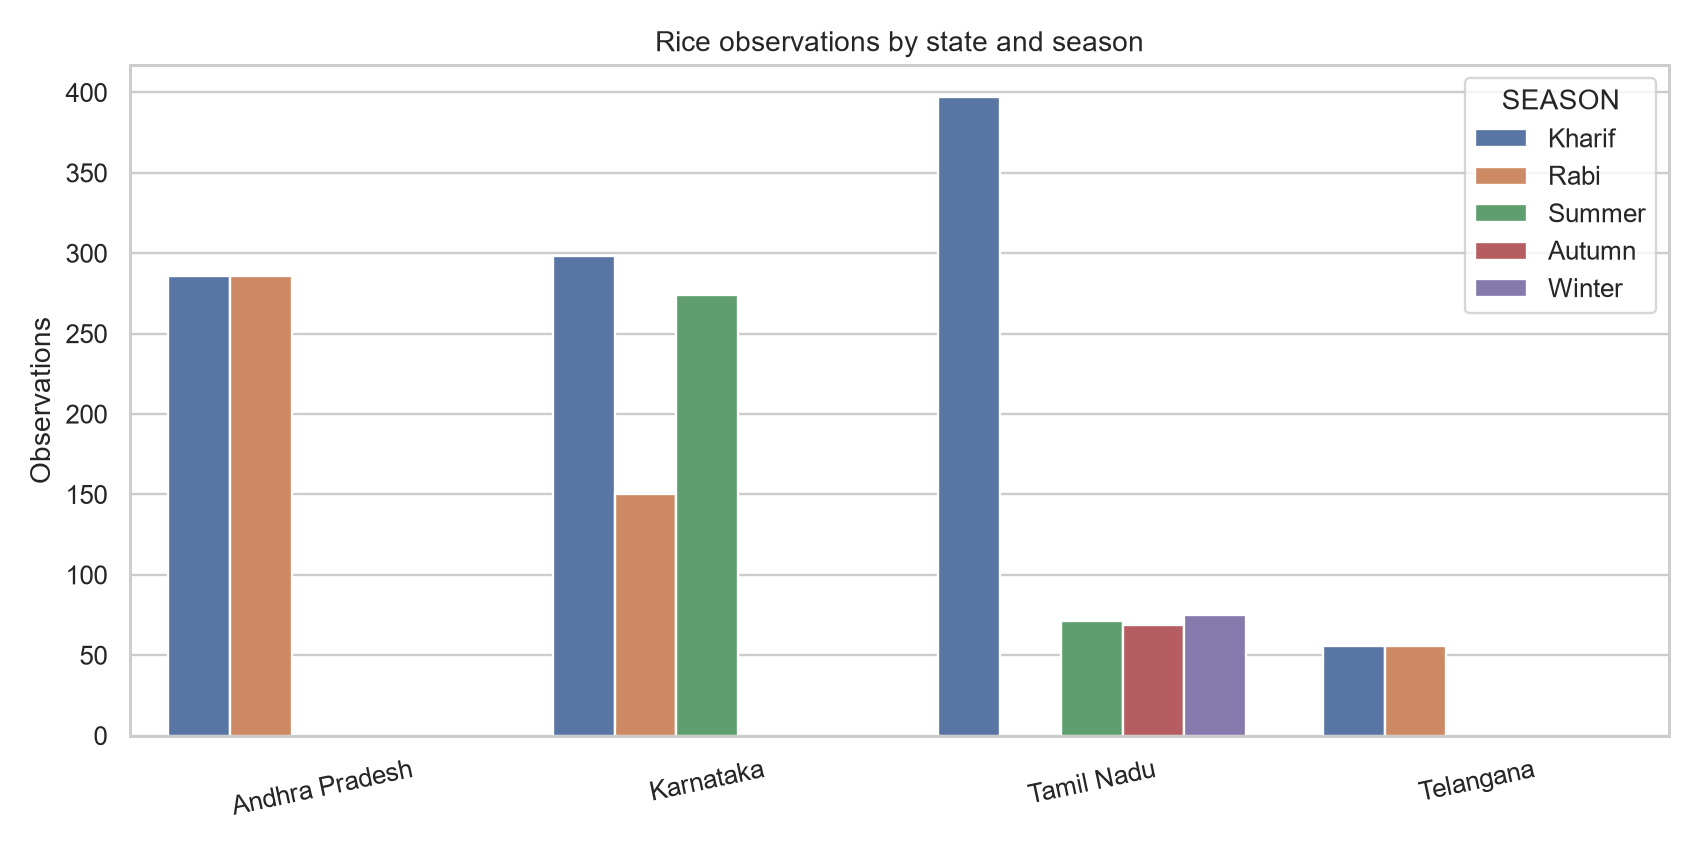

In [ ]:
from IPython.display import Image, display
display(Image(filename=str(repo / "docs/figures/01_observation_coverage.png")))

### Recorded yield distribution

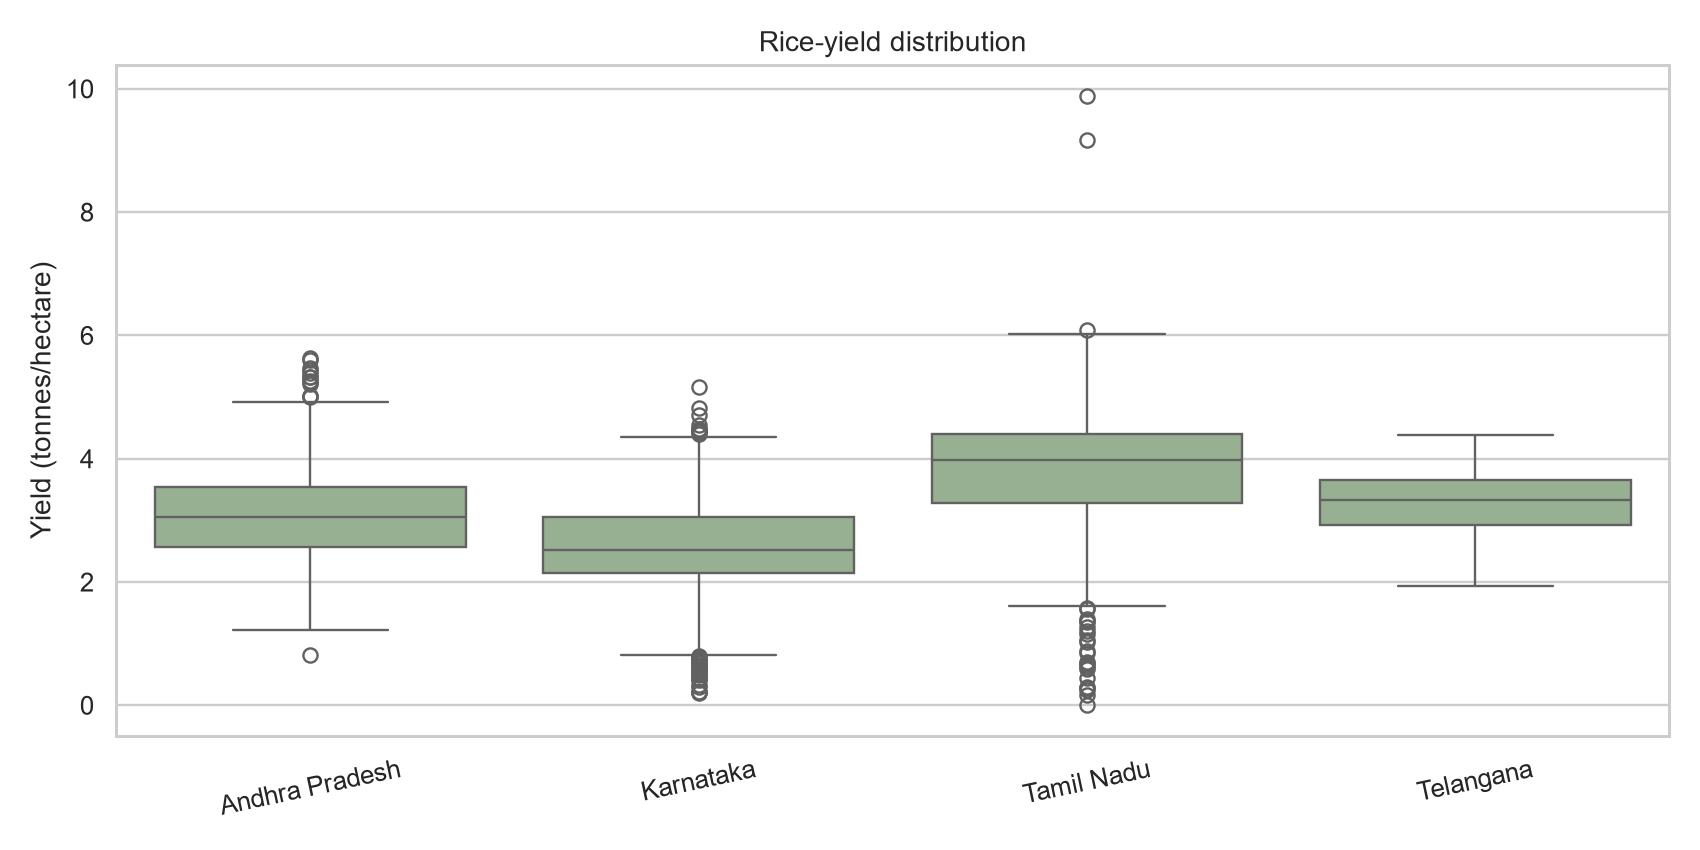

In [ ]:
from IPython.display import Image, display
display(Image(filename=str(repo / "docs/figures/02_yield_distribution.png")))

### Recorded annual mean yield

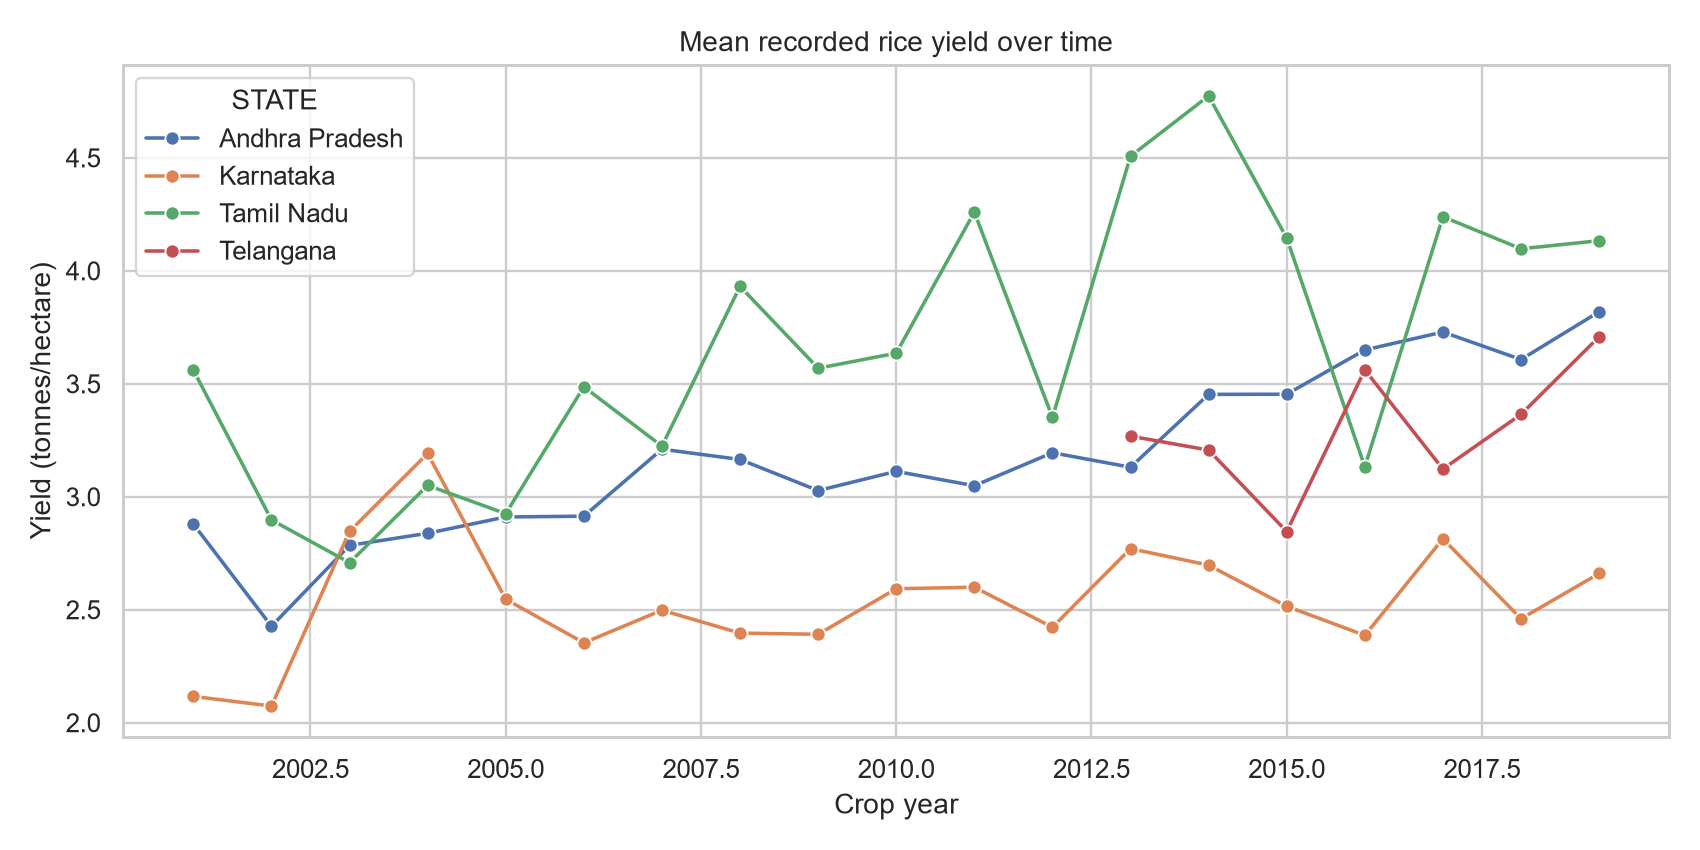

In [ ]:
from IPython.display import Image, display
display(Image(filename=str(repo / "docs/figures/03_annual_yield_by_state.png")))

### Feature correlations: associations, not causes

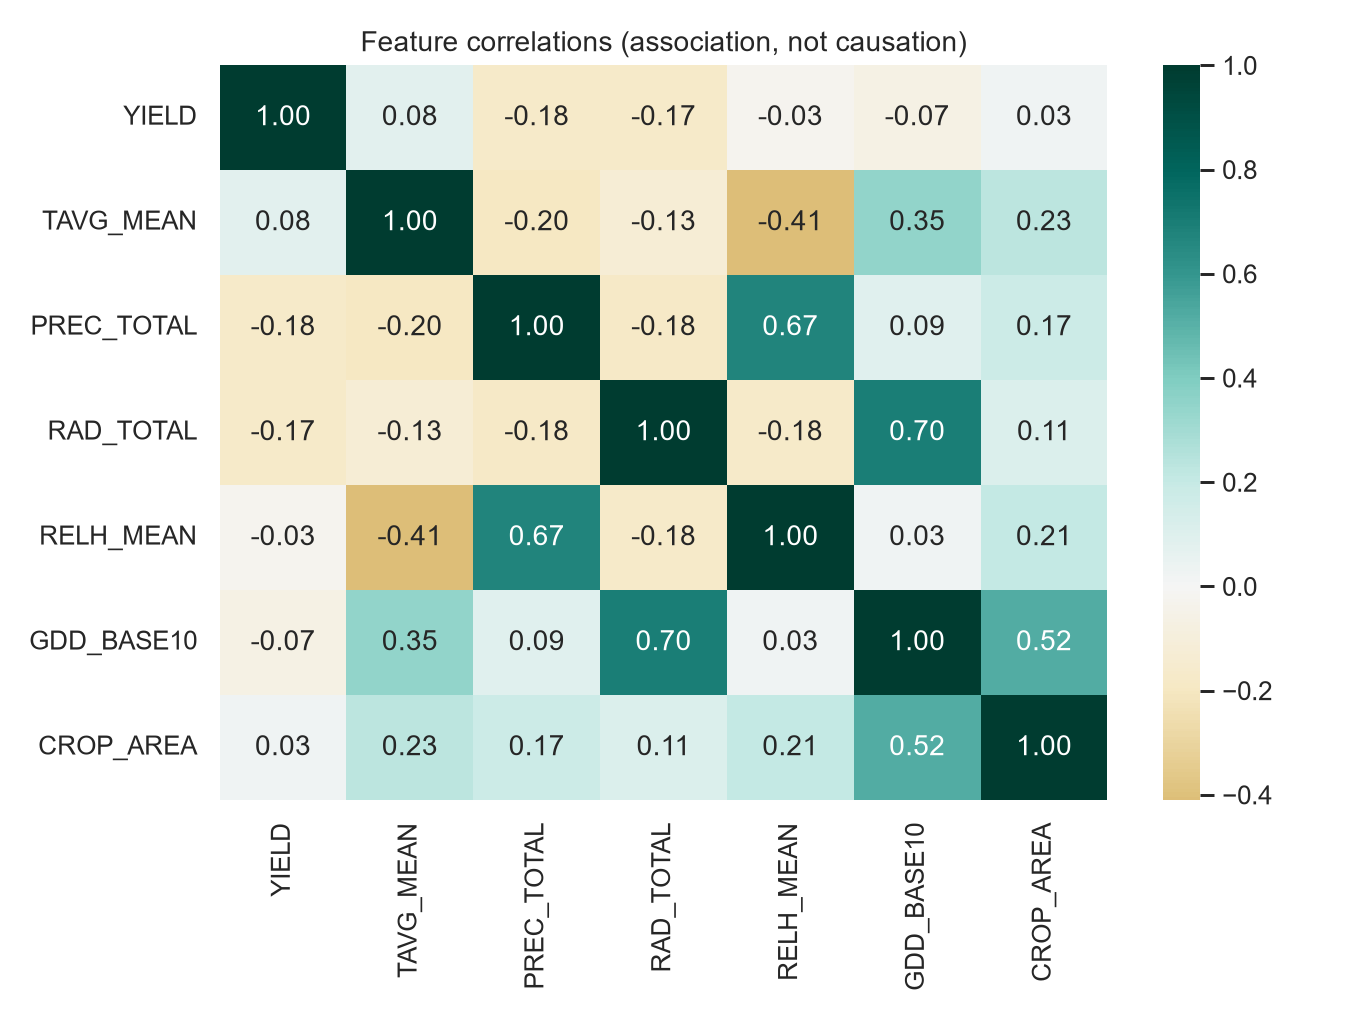

In [ ]:
from IPython.display import Image, display
display(Image(filename=str(repo / "docs/figures/04_feature_correlation.png")))

### Raw inputs compared with standardized inputs

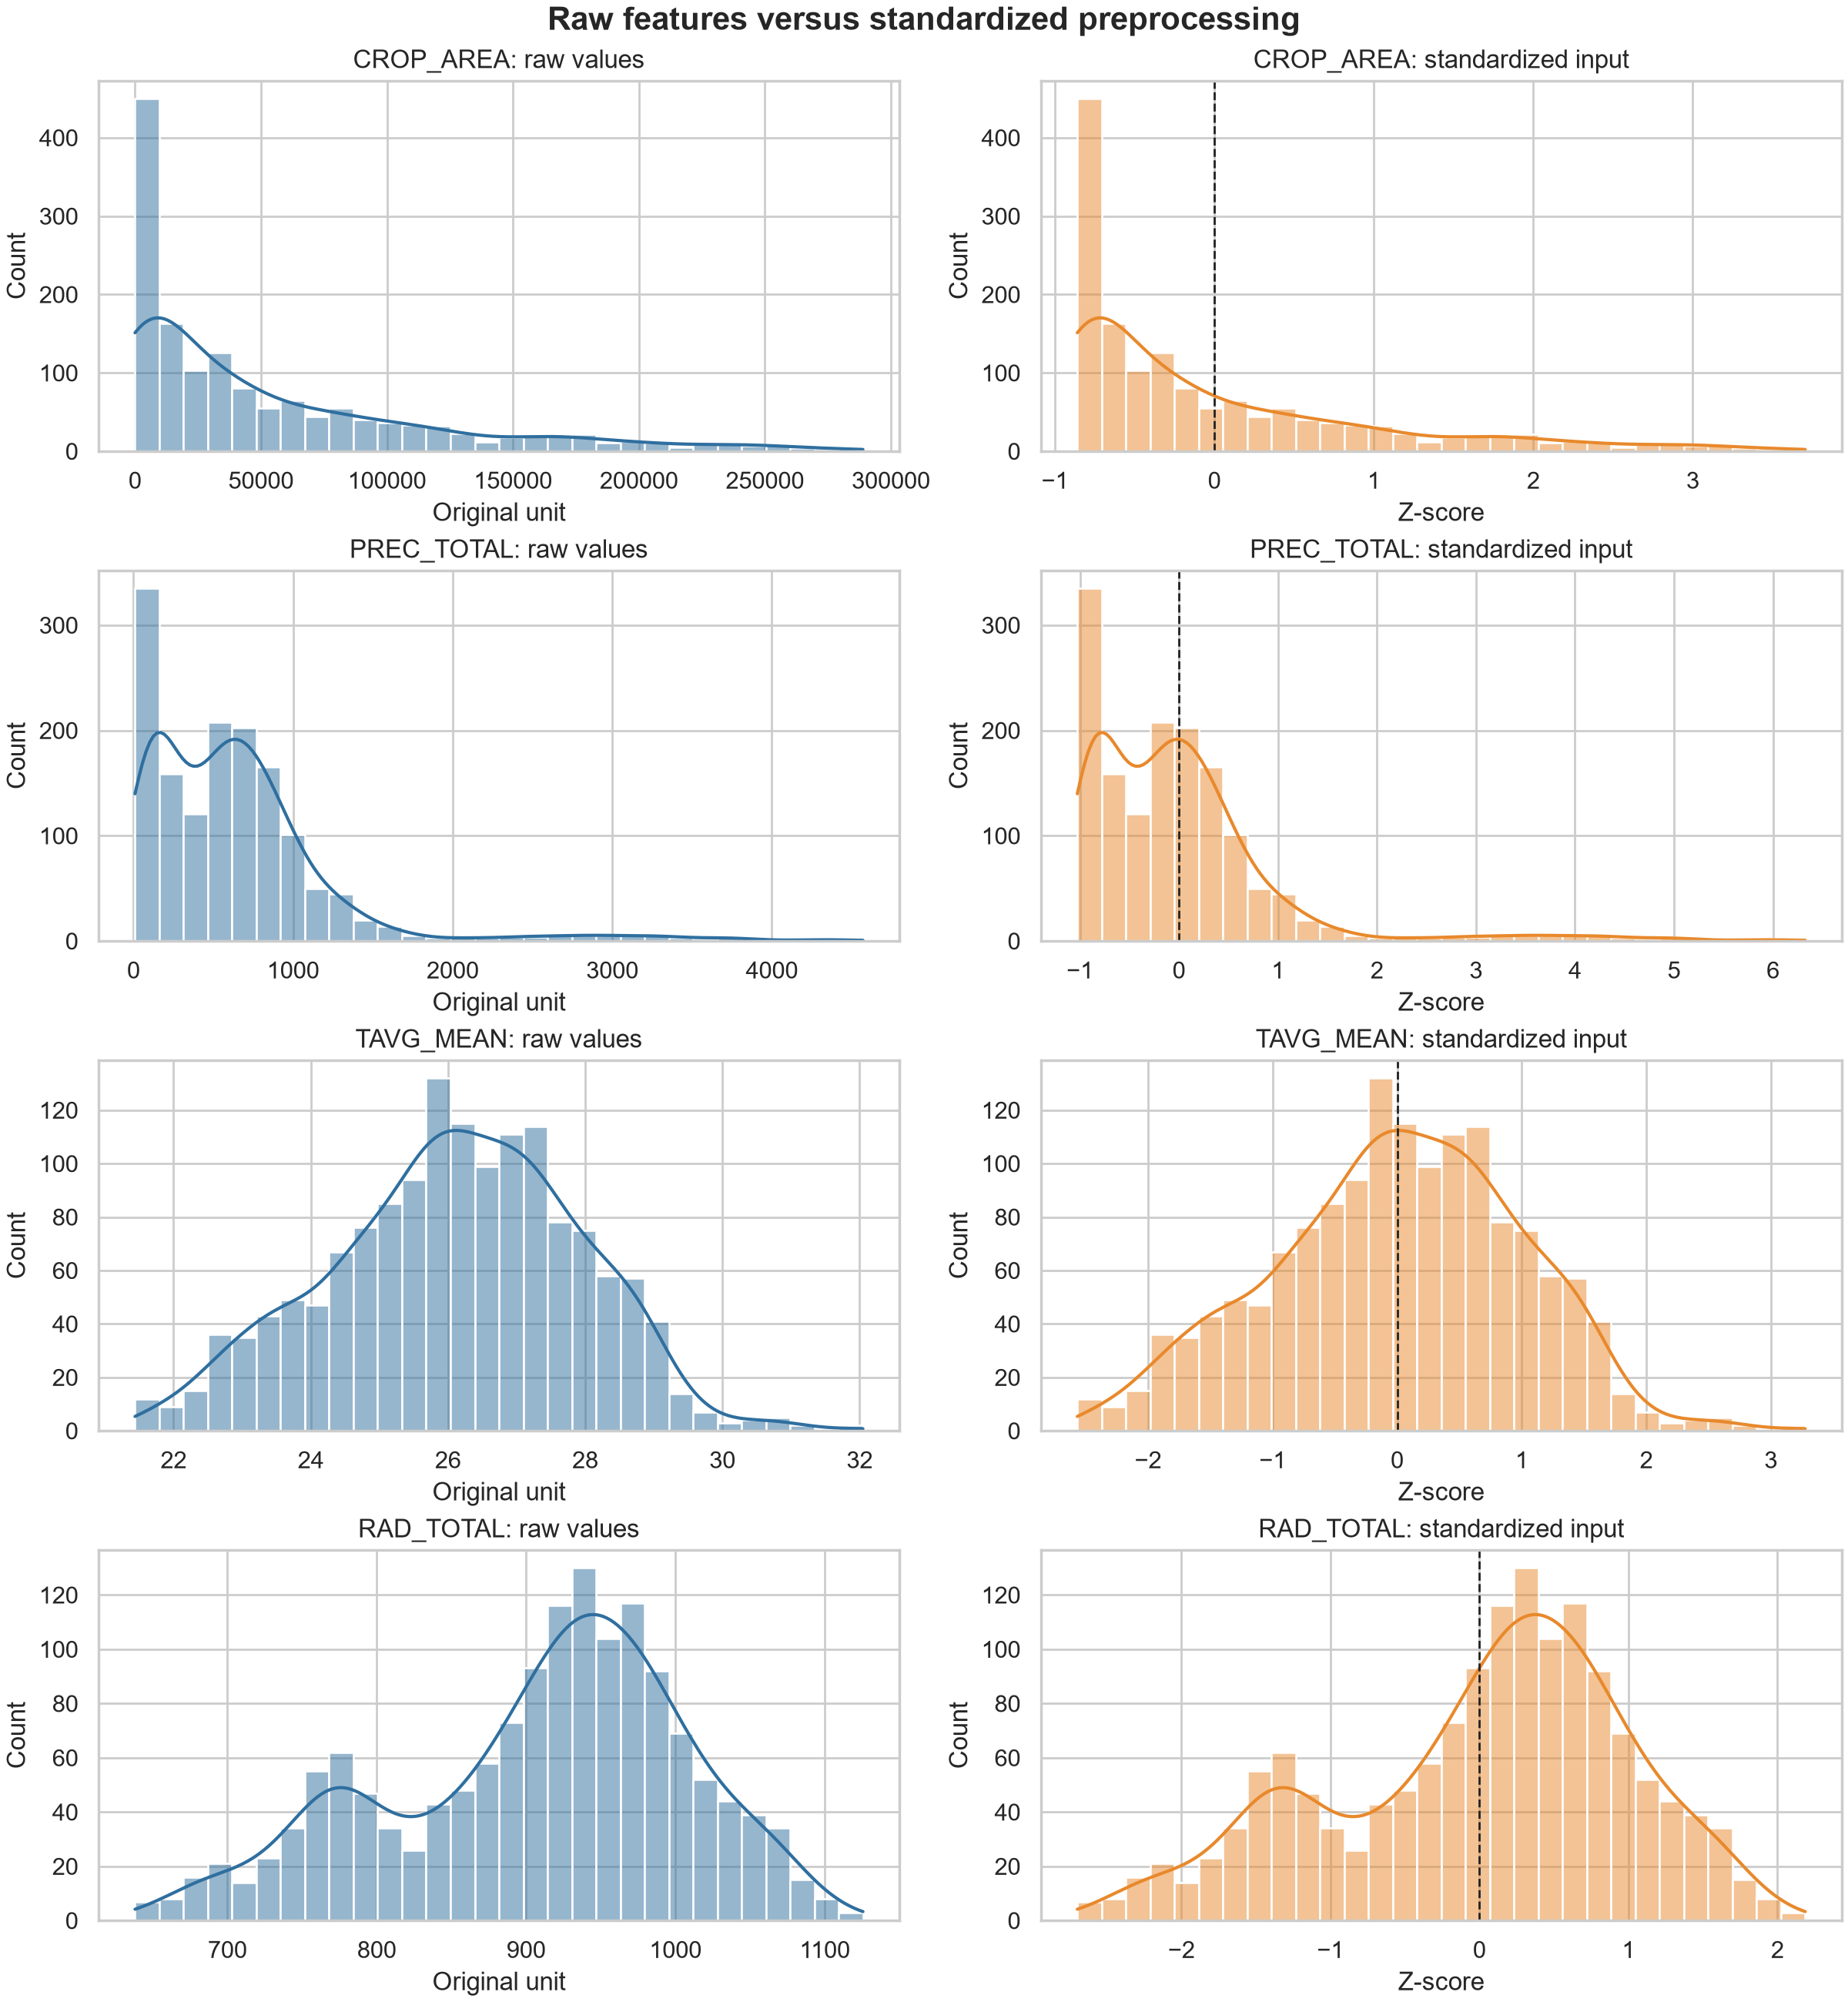

In [ ]:
from IPython.display import Image, display
display(Image(filename=str(repo / "docs/figures/05_raw_vs_standardized_features.png")))

### Actual DAE reconstructions

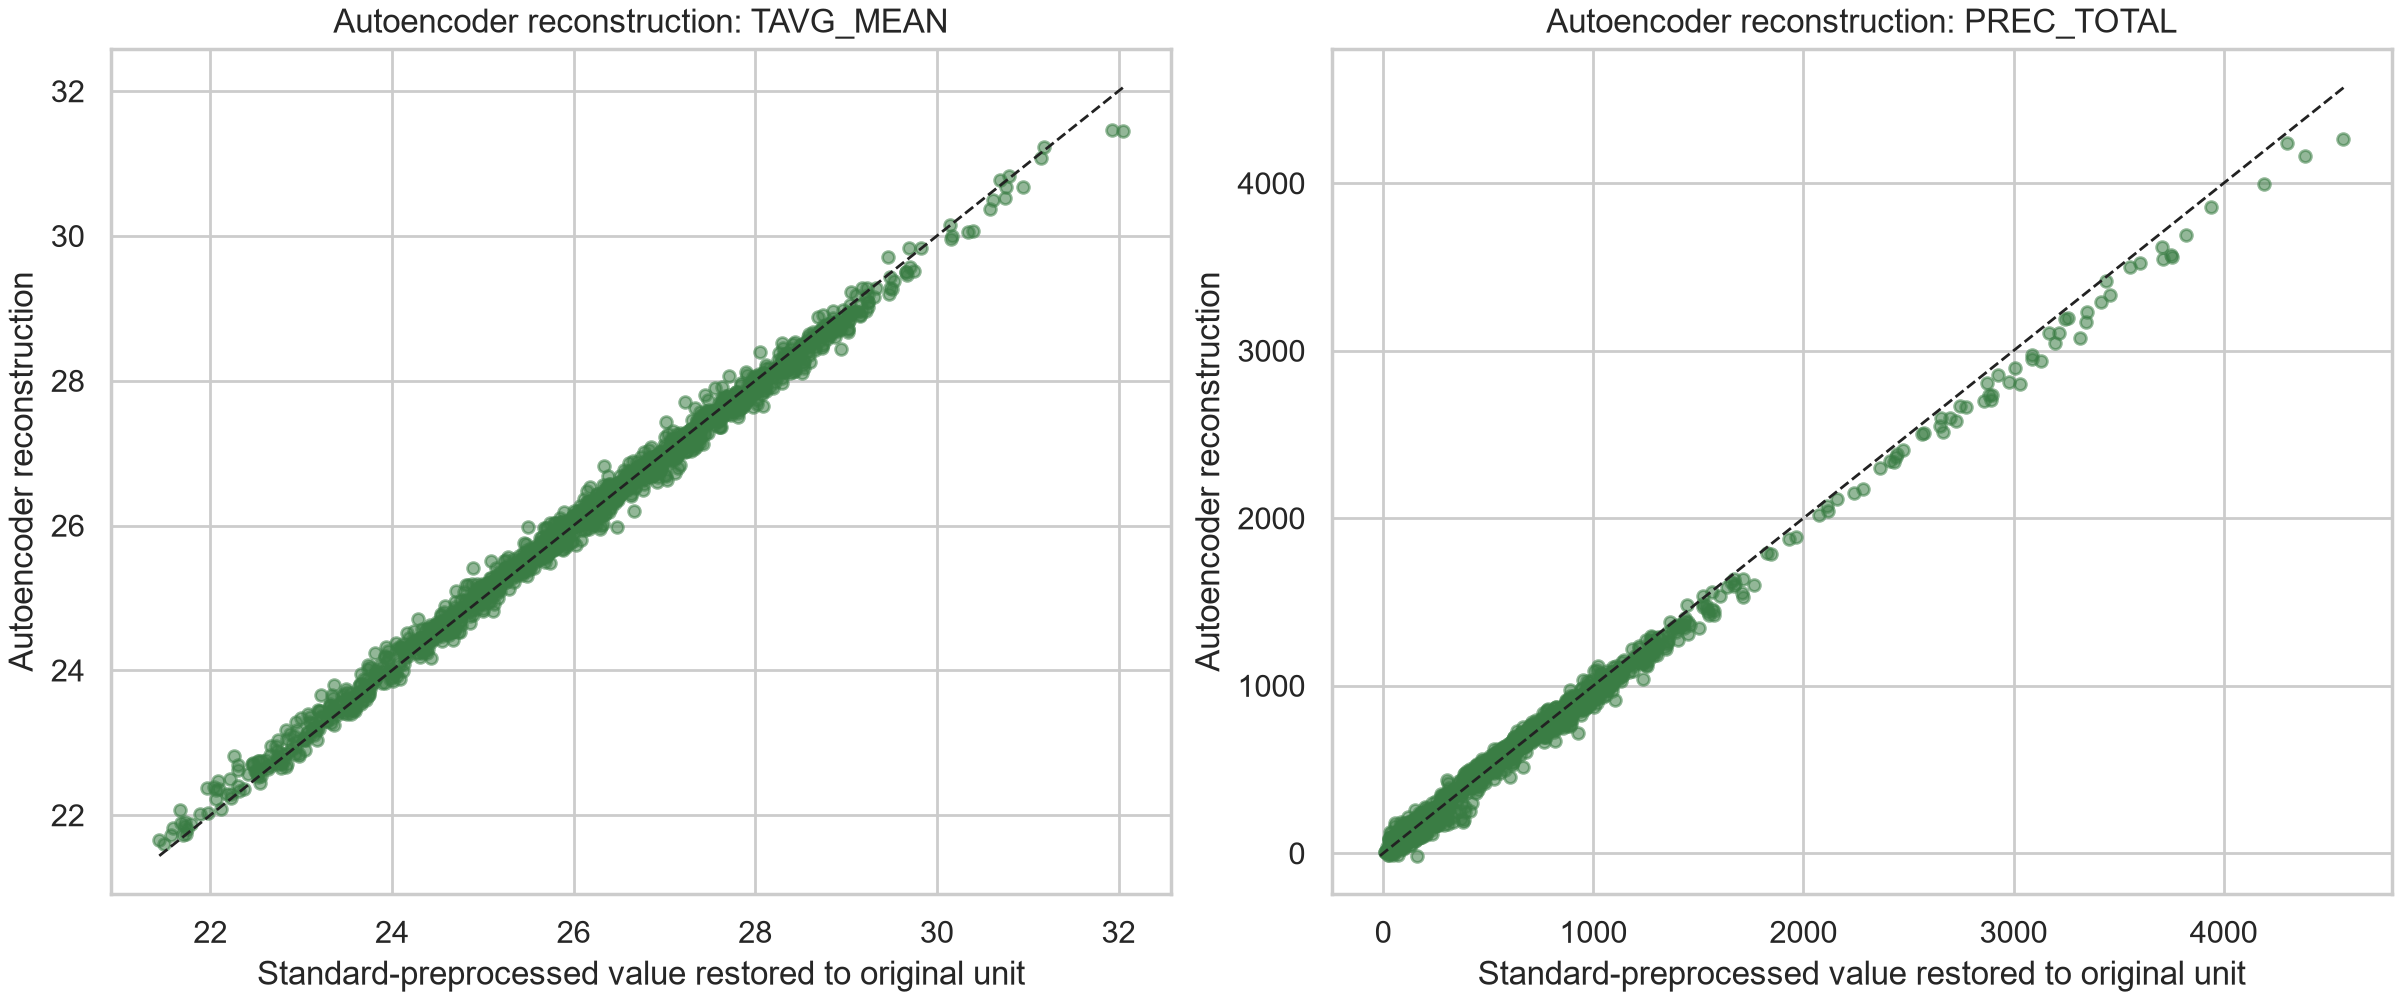

In [ ]:
from IPython.display import Image, display
display(Image(filename=str(repo / "docs/figures/06_autoencoder_reconstruction.png")))

### Actual DAE training/validation history

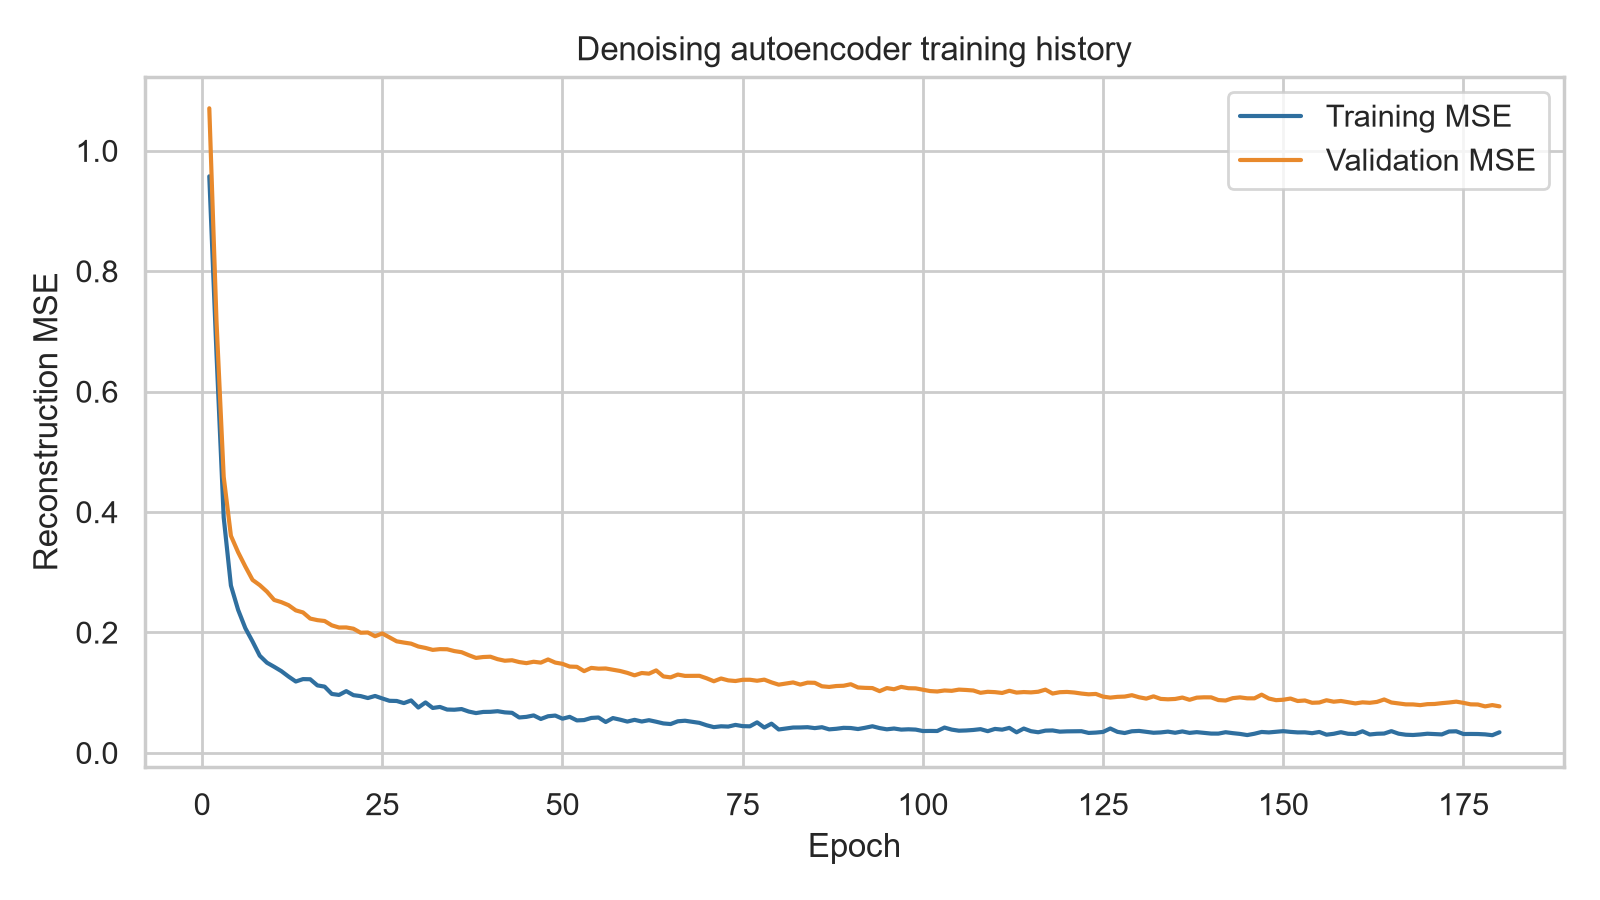

In [ ]:
from IPython.display import Image, display
display(Image(filename=str(repo / "docs/figures/07_autoencoder_training_loss.png")))

## 8. What is used for supervised training?
Use DATASET/training/standard/train.csv or autoencoder/train.csv. Keep validation.csv and test.csv separate. Raw sources and rice_master.csv remain preserved. The fitted preprocessing DAE is not a fitted yield predictor.

See docs/MODEL_REGISTRY.md and docs/Crop_Workflow.pdf for all model names, computational diagrams, limitations and future steps. The Verdant beta uses illustrative values only.